<a href="https://colab.research.google.com/github/jawadwali3454/AI-AND-ML/blob/main/Predicting_Student_Academic_Performance_Using_Supervised_Machine_Learning_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving student.zip to student.zip


In [5]:
import zipfile

with zipfile.ZipFile('student.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [6]:
import os

os.listdir('dataset')

['student-mat.csv', 'student-merge.R', 'student-por.csv', 'student.txt']

In [7]:
import os

print(os.listdir())
print(os.listdir('dataset'))

['.config', 'student.zip', 'dataset', 'sample_data']
['student-mat.csv', 'student-merge.R', 'student-por.csv', 'student.txt']


In [8]:
import pandas as pd

data = pd.read_csv('dataset/student-mat.csv', sep=';')

In [9]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
data.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

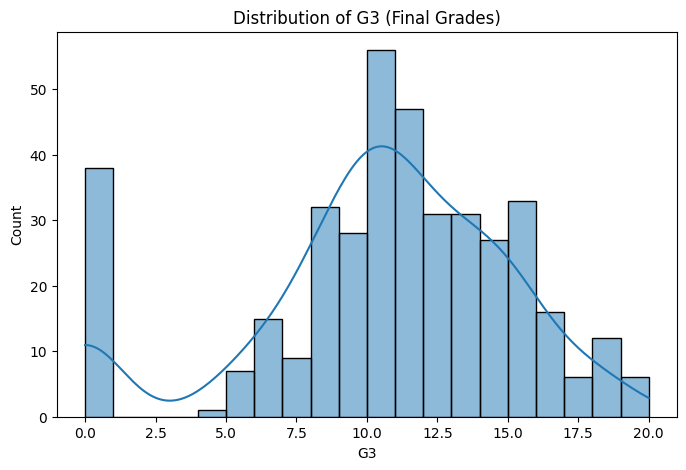

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['G3'], bins=20, kde=True)
plt.title("Distribution of G3 (Final Grades)")
plt.show()

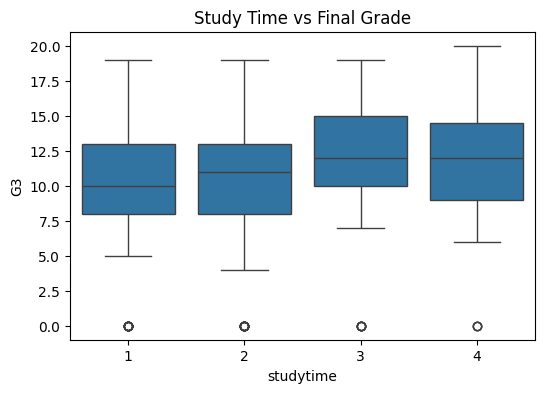

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['studytime'], y=data['G3'])
plt.title("Study Time vs Final Grade")
plt.show()

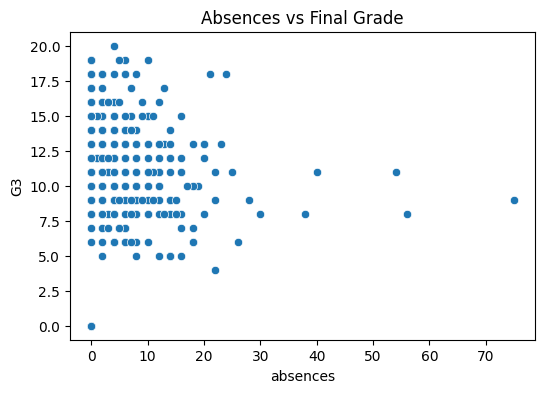

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['absences'], y=data['G3'])
plt.title("Absences vs Final Grade")
plt.show()

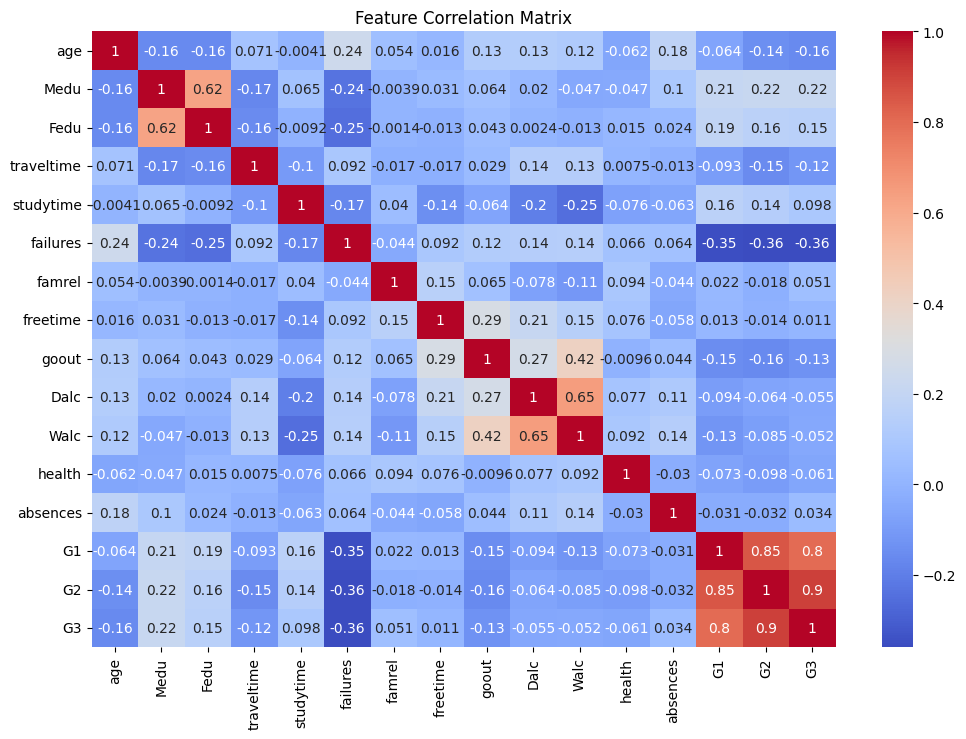

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

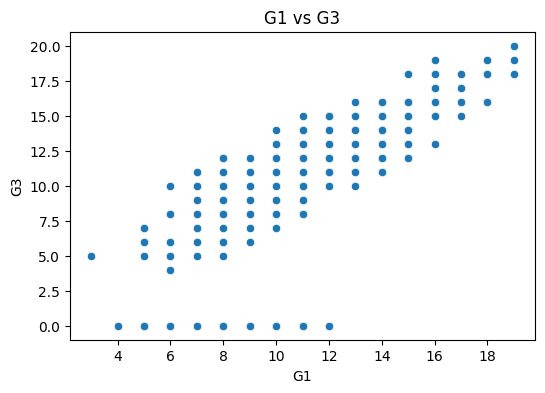

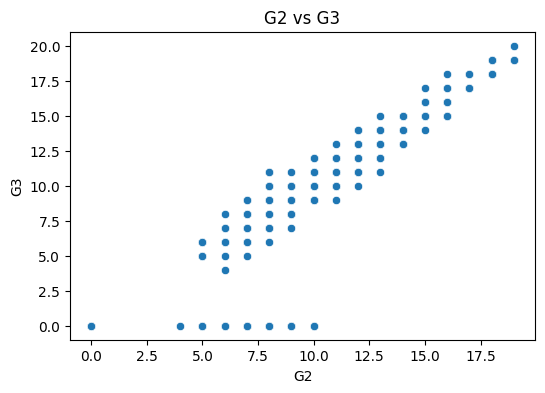

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['G1'], y=data['G3'])
plt.title("G1 vs G3")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=data['G2'], y=data['G3'])
plt.title("G2 vs G3")
plt.show()

In [19]:
X = data[['studytime', 'failures', 'absences', 'G1', 'G2']]
y = data['G3']

# **Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Model Training (Linear Regression)**

In [21]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [22]:
# Prediction
y_pred_lr = lr_model.predict(X_test)

**Model Evaluation**



In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 1.3394159082670907
R2 Score: 0.7821754247320557


**Actual vs Predicted (Linear Regression)**

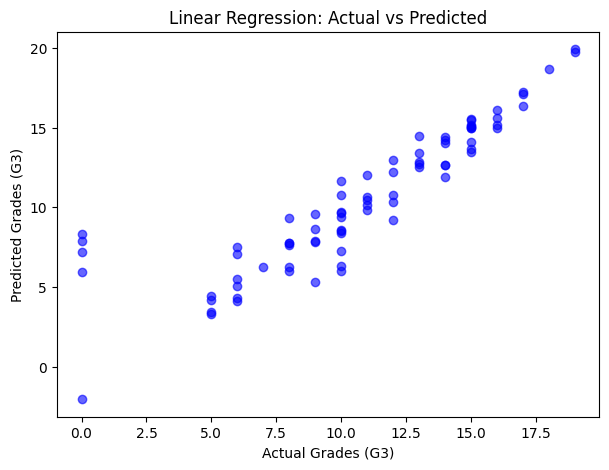

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)

plt.xlabel("Actual Grades (G3)")
plt.ylabel("Predicted Grades (G3)")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

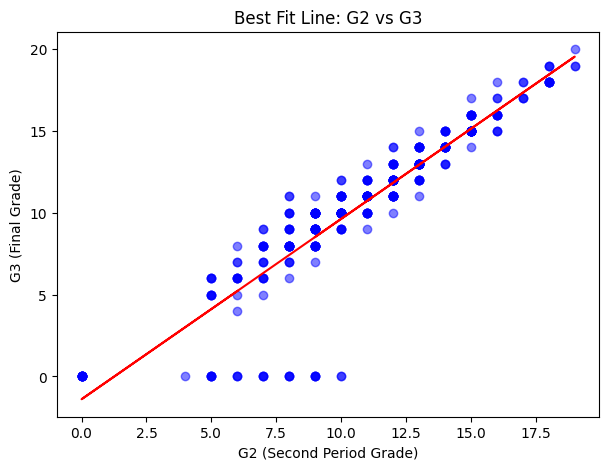

In [25]:
import numpy as np
import matplotlib.pyplot as plt

X_simple = data[['G2']]
y_simple = data['G3']

from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

y_line = model_simple.predict(X_simple)

plt.figure(figsize=(7,5))
plt.scatter(X_simple, y_simple, color='blue', alpha=0.5)
plt.plot(X_simple, y_line, color='red')

plt.xlabel("G2 (Second Period Grade)")
plt.ylabel("G3 (Final Grade)")
plt.title("Best Fit Line: G2 vs G3")

plt.show()

In [27]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

results.head(10)

,Actual,Predicted
78,10,6.011138
371,12,12.203063
248,5,3.425839
55,10,8.522430
390,9,7.873003
223,13,12.704786
42,18,18.692596
234,6,7.100112
316,0,7.228856
116,14,12.638812


In [28]:
results["Error"] = results["Actual"] - results["Predicted"]
results.head(10)

,Actual,Predicted,Error
78,10,6.011138,3.988862
371,12,12.203063,-0.203063
248,5,3.425839,1.574161
55,10,8.522430,1.477570
390,9,7.873003,1.126997
223,13,12.704786,0.295214
42,18,18.692596,-0.692596
234,6,7.100112,-1.100112
316,0,7.228856,-7.228856
116,14,12.638812,1.361188


**Random Forest Regressor**

In [29]:
from sklearn.ensemble import RandomForestRegressor

**Model Train**

In [30]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Prediction**

In [31]:
y_pred_rf = rf_model.predict(X_test)

**Evaluation**

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 1.0525179827205144
R2 Score: 0.8725239455080609


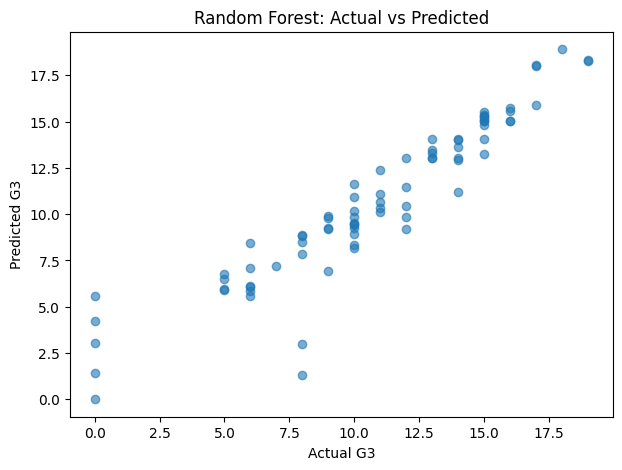

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

**COMPARING**

In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,R2 Score
0,Linear Regression,1.339416,0.782175
1,Random Forest,1.052518,0.872524


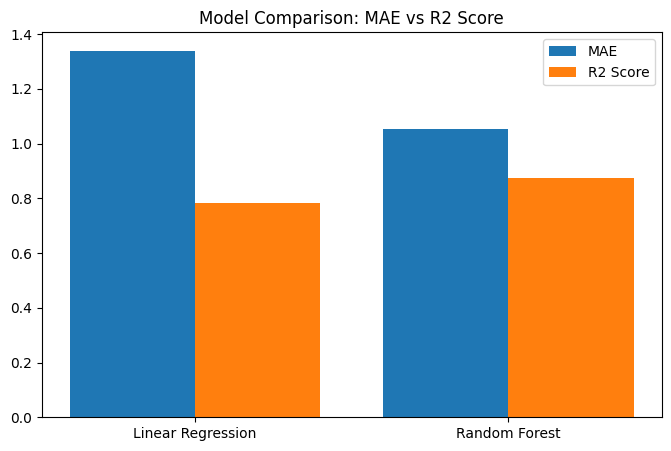

In [35]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Random Forest"]

mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_rf)
]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

x = np.arange(len(models))

plt.figure(figsize=(8,5))

# MAE Bar
plt.bar(x - 0.2, mae_scores, width=0.4, label="MAE")

# R2 Bar
plt.bar(x + 0.2, r2_scores, width=0.4, label="R2 Score")

plt.xticks(x, models)
plt.title("Model Comparison: MAE vs R2 Score")
plt.legend()

plt.show()

In [36]:
import numpy as np

# Example student data
new_student = np.array([[2, 0, 4, 10, 12]])

prediction = rf_model.predict(new_student)

print("Predicted Final Grade (G3):", prediction[0])

Predicted Final Grade (G3): 11.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


**Multiple Students Test**

In [37]:
new_data = np.array([
    [1, 2, 10, 8, 9],
    [3, 0, 2, 14, 15],
    [2, 1, 6, 11, 12]
])

predictions = rf_model.predict(new_data)

print("Predictions:", predictions)

Predictions: [ 9.01  15.674 12.24 ]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
